# 04 推論分析 — Two-Sample Inference
**Research Question 2: Gender and Current Alcohol Use**

- **Group variable:** `WhatIsYourSex` (1 = Male, 2 = Female)
- **Response variable:** `CurrentAlcoholUse` (binary after recoding)
- **Method:** Two-Proportion Z-Test

## 1. 載入套件與資料 | Load Libraries & Data

In [1]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt

PROJECT = r'C:\Users\88690\OneDrive\桌面\project-cycle-3-main'

df = pd.read_csv(f'{PROJECT}/data/Processed/YRBS_2007_cleaned.csv')
print('資料維度 Shape:', df.shape)
df[['WhatIsYourSex', 'CurrentAlcoholUse']].head(10)

資料維度 Shape: (12659, 2)


,WhatIsYourSex,CurrentAlcoholUse
0,1.0,1.0
1,1.0,1.0
2,1.0,1.0
3,1.0,1.0
4,1.0,1.0
5,1.0,2.0
6,1.0,1.0
7,1.0,2.0
8,1.0,1.0
9,1.0,1.0


## 2. 重編碼 | Recoding

**規則:**
- `CurrentAlcoholUse`: 1 → 0 (no drinking), 2–7 → 1 (current drinker)
- `WhatIsYourSex`: 1 → Male, 2 → Female

In [5]:
df_clean = df[['WhatIsYourSex', 'CurrentAlcoholUse']].dropna()
df_clean = df_clean[df_clean['WhatIsYourSex'].isin([1.0, 2.0])]

df_clean['alcohol_binary'] = np.where(df_clean['CurrentAlcoholUse'] == 1.0, 0, 1)
df_clean['sex_label'] = df_clean['WhatIsYourSex'].map({1.0: 'Male', 2.0: 'Female'})

print('清理後資料維度:', df_clean.shape)
print()
print('alcohol_binary 分佈 (0=no, 1=yes):')
print(df_clean['alcohol_binary'].value_counts())

清理後資料維度: (12659, 4)

alcohol_binary 分佈 (0=no, 1=yes):
alcohol_binary
0    6942
1    5717
Name: count, dtype: int64


## 3. 分組統計 | Group Statistics

In [6]:
male   = df_clean[df_clean['sex_label'] == 'Male']['alcohol_binary']
female = df_clean[df_clean['sex_label'] == 'Female']['alcohol_binary']

n_male,   n_female   = len(male),    len(female)
yes_male, yes_female = male.sum(),   female.sum()
p_male,   p_female   = yes_male/n_male, yes_female/n_female

print('=== 分組統計 ===')
print(f'Male:   n={n_male},  drinkers={yes_male},  p̂={p_male:.4f}')
print(f'Female: n={n_female}, drinkers={yes_female}, p̂={p_female:.4f}')
print(f'Difference (Male - Female): {p_male - p_female:.4f}')

=== 分組統計 ===
Male:   n=6425,  drinkers=2864,  p̂=0.4458
Female: n=6234, drinkers=2853, p̂=0.4577
Difference (Male - Female): -0.0119


## 4. 假設設定 | Hypotheses

$$H_0: p_{male} - p_{female} = 0$$
$$H_1: p_{male} - p_{female} \neq 0$$

- **Test type:** Two-sided
- **Significance level:** $\alpha = 0.05$

## 5. Two-Proportion Z-Test

In [7]:
count = np.array([yes_male, yes_female])
nobs  = np.array([n_male, n_female])

z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')

print('=== Two-Proportion Z-Test 結果 ===')
print(f'Z-statistic : {z_stat:.4f}')
print(f'P-value     : {p_value:.4f}')
print()
if p_value < 0.05:
    print('結論: p-value < 0.05 → Reject H₀')
    print('      兩組飲酒比例有顯著差異 (statistically significant)')
else:
    print('結論: p-value ≥ 0.05 → Fail to reject H₀')
    print('      沒有足夠證據顯示兩組飲酒比例有差異')

=== Two-Proportion Z-Test 結果 ===
Z-statistic : -1.3442
P-value     : 0.1789

結論: p-value ≥ 0.05 → Fail to reject H₀
      沒有足夠證據顯示兩組飲酒比例有差異


## 6. 95% 信賴區間 | Confidence Interval

In [8]:
diff = p_male - p_female
se   = np.sqrt(p_male*(1-p_male)/n_male + p_female*(1-p_female)/n_female)
ci_lower = diff - 1.96 * se
ci_upper = diff + 1.96 * se

print('=== 95% 信賴區間 (Male - Female) ===')
print(f'Difference : {diff:.4f}')
print(f'SE         : {se:.4f}')
print(f'95% CI     : ({ci_lower:.4f}, {ci_upper:.4f})')

=== 95% 信賴區間 (Male - Female) ===
Difference : -0.0119
SE         : 0.0088
95% CI     : (-0.0292, 0.0054)


## 7. 視覺化 | Visualization

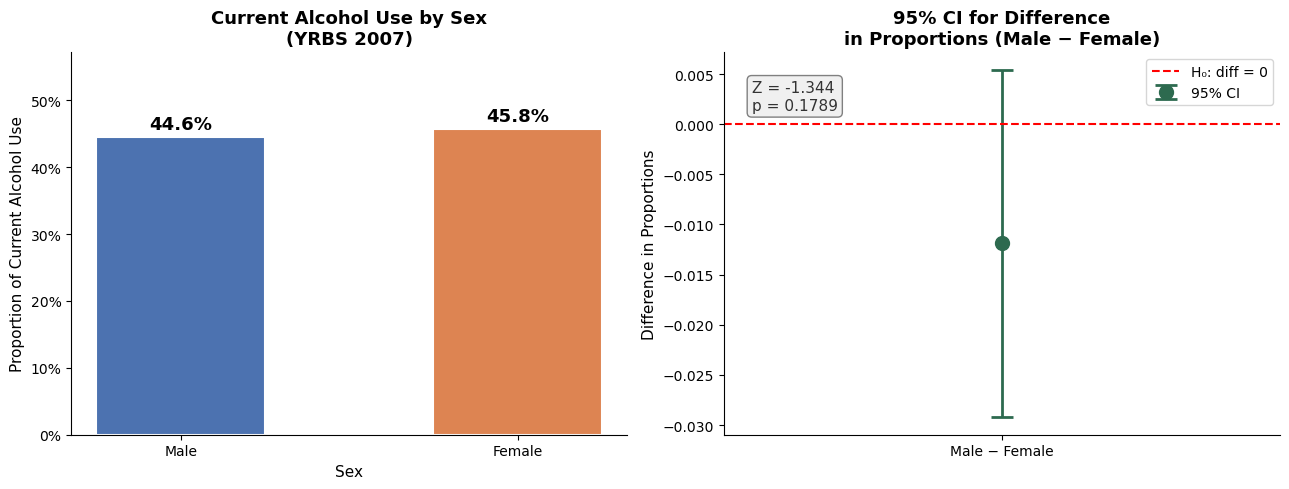

圖表已儲存至 outputs/figures/inference_alcohol_by_sex.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#4C72B0', '#DD8452']

# --- 7a. 比例比較 bar chart ---
ax = axes[0]
bars = ax.bar(['Male', 'Female'], [p_male, p_female],
color=colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, prop in zip(bars, [p_male, p_female]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{prop:.1%}',
            ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(p_male, p_female) * 1.25)
ax.set_ylabel('Proportion of Current Alcohol Use', fontsize=11)
ax.set_xlabel('Sex', fontsize=11)
ax.set_title('Current Alcohol Use by Sex\n(YRBS 2007)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.spines[['top', 'right']].set_visible(False)

# --- 7b. 信賴區間圖 ---
ax = axes[1]
ax.errorbar(x=0, y=diff, yerr=[[diff - ci_lower], [ci_upper - diff]],
            fmt='o', color='#2d6a4f', markersize=10,
            capsize=8, capthick=2, linewidth=2, label='95% CI')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label='H₀: diff = 0')
ax.set_xlim(-0.5, 0.5)
ax.set_xticks([0])
ax.set_xticklabels(['Male − Female'])
ax.set_ylabel('Difference in Proportions', fontsize=11)
ax.set_title('95% CI for Difference\nin Proportions (Male − Female)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.annotate(f'Z = {z_stat:.3f}\np = {p_value:.4f}',
            xy=(0.05, 0.85), xycoords='axes fraction',
            fontsize=11, color='#333333',
            bbox=dict(boxstyle='round,pad=0.3', fc='#f0f0f0', ec='grey'))

plt.tight_layout()
plt.savefig(f'{PROJECT}/outputs/figures/inference_alcohol_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()
print('圖表已儲存至 outputs/figures/inference_alcohol_by_sex.png')

## 8. 儲存結果 | Save Results

In [10]:
results = pd.DataFrame({
    'Group': ['Male', 'Female'],
    'n': [n_male, n_female],
    'Drinkers': [yes_male, yes_female],
    'Proportion': [round(p_male, 4), round(p_female, 4)],
    'Z_statistic': [round(z_stat, 4), ''],
    'P_value': [round(p_value, 4), ''],
    'CI_lower': [round(ci_lower, 4), ''],
    'CI_upper': [round(ci_upper, 4), '']
})
results.to_csv(f'{PROJECT}/outputs/tables/inference_alcohol_by_sex.csv', index=False)
print('結果已儲存至 outputs/tables/inference_alcohol_by_sex.csv')
print()
print('=== 04 推論分析完成 ===')

結果已儲存至 outputs/tables/inference_alcohol_by_sex.csv

=== 04 推論分析完成 ===
